# Week 4 — From Data to Models

**Programming and Numerical Methods for Economics (ECNM10115)** · The University of Edinburgh

**Learning goals.** Random numbers and seeds; drawing from (and building your own) distributions; Monte Carlo vs Gauss–Hermite quadrature integration; simulating AR(1) processes; Markov chains with `quantecon`.

> **How to work through this notebook:** run every cell in order (`Shift+Enter`). When you reach a result, pause and predict it before running — that habit is what turns reading into learning. Experiment: change parameters, break things, re-run.
>
> This notebook uses the `quantecon` package: `pip install quantecon` (in Colab: `!pip install quantecon`).


### <center> Programming and Numerical Methods for Economics  
##### <center> Lecture 4: From Data to Models anipulation and Data Analysis

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(23)  # fix the seed at the beginning and only once.
import time
import os
os.chdir('C:/Users/jzurita/OneDrive - University of Edinburgh/Courses/Programming Numerical Methods/Week 4')
from functions import gauss_hermite_1d  # you need to save the file in your Working directory.
import seaborn as sns
import quantecon as qe   #first you need to install the quantecon package: here is how https://anaconda.org/conda-forge/quantecon

# Use the following line if you need to install quantecon
#!pip install quantecon 

In [35]:
import warnings
warnings.filterwarnings('ignore') 

### Random numbers

In [37]:
# Let's generate 1000 draws form a x~N(0,1)
x = np.random.normal(loc=0,scale=1,size=1000)
x[0:4]

array([ 0.66698806,  0.02581308, -0.77761941,  0.94863382])

#### Setting a seed: (example)

In [39]:
np.random.seed(68)
x1 = np.random.normal(loc=0,scale=1,size=1000) 
x2 = np.random.normal(loc=0,scale=1,size=1000) 
np.random.seed(68)
x3 = np.random.normal(loc=0,scale=1,size=1000)
x4 = np.random.normal(loc=0,scale=1,size=1000)
print(x1[0:4])
print(x2[0:4])
print(x3[0:4])
print(x4[0:4])

[-0.94447636  0.19994362 -1.54035342  0.83804177]
[ 0.59233049 -0.85910019 -0.45770469 -0.31261349]
[-0.94447636  0.19994362 -1.54035342  0.83804177]
[ 0.59233049 -0.85910019 -0.45770469 -0.31261349]


#### Random numbers from special distributions

In [41]:
N=10000
# Normal distribution x~N(mu, sigma^2)
mu=1
sigma=1
x = np.random.normal(mu,sigma,N)  #scale=sigma

# Uniform distribution x~U(a,b)
a=0
b=5
y = np.random.uniform(low=a,high=b,size=N)

#  Log-normal distribution: z st ln(z)~N(mu, sigma^2)
z = np.random.lognormal(mean=mu, sigma=sigma, size=N)

# alternatively
z2 = np.exp(x)

# Poisson distribution w~P(lambda)
w = np.random.poisson(lam=1,size=N)

For plotting distributions we have hist from matplotlib, displot, distplot, kdeplot from seaborn.


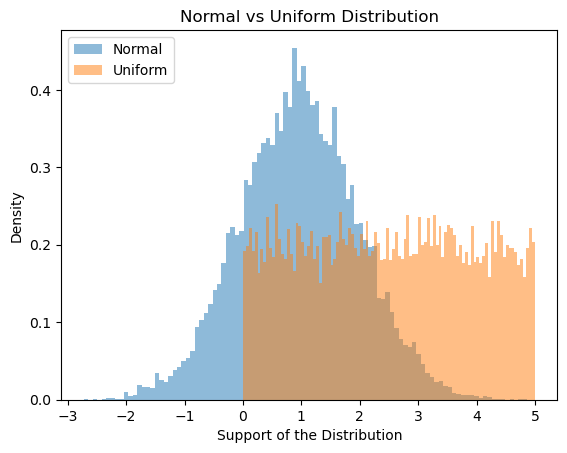

In [43]:
# Normal distribution vs uniform distribution
fig, ax = plt.subplots() 
ax.hist(x,bins=100, density=True,alpha=0.5,label='Normal')
ax.hist(y,bins=100,density=True,alpha=0.5,label='Uniform')
#ax.hist(z,bins=100,density=True,alpha=0.5,label='Poisson')
ax.legend(loc='upper left'); # note: the ; stops output from being printed
plt.title('Normal vs Uniform Distribution')
plt.ylabel('Density')
plt.xlabel('Support of the Distribution')
#ax.set_xlim([-2,20])
plt.show()

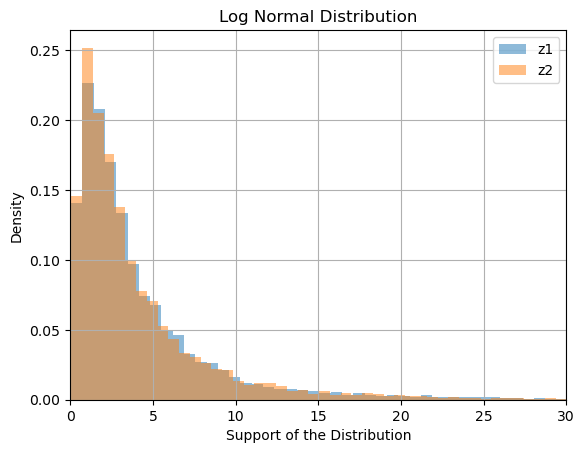

In [44]:
# Comparing the log-normal distributions
fig, ax = plt.subplots() 
ax.hist(z,bins=200,density=True,alpha=0.5,label='z1')
ax.hist(z2,bins=200,density=True,alpha=0.5,label='z2')
plt.title('Log Normal Distribution')
plt.ylabel('Density')
plt.xlabel('Support of the Distribution')
ax.legend(loc='upper right'); # note: the ; stops output from being printed
ax.set_xlim([0,30])
plt.grid()
plt.show()

#### Creating our own distributions


Define support of the distribution

In [47]:
v_sup = np.array([0,1,2,3,4])

Define probabilities (positive numbers, sum must be equal to 1)

In [49]:
v_p = [0.4, 0.1, 0.1, 0.2,0.2]
print('Prob of v sum to 1?', sum(v_p)==1)

Prob of v sum to 1? True


In [50]:
# c. Get draws from distribution
v = np.random.choice(v_sup,size=N,p=v_p)
print(v[0:6])

[2 2 4 0 4 2]


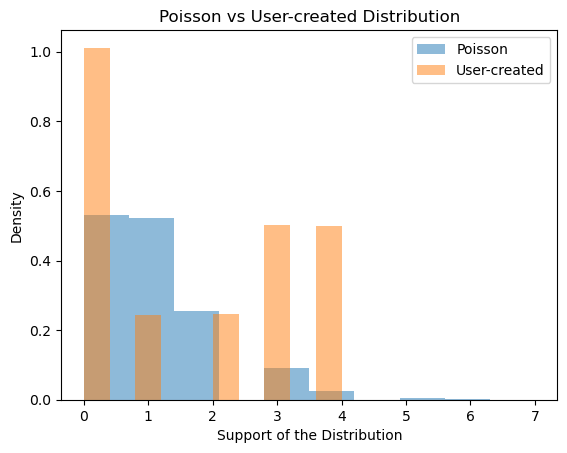

In [51]:
fig, ax = plt.subplots() 
ax.hist(w,density=True,alpha=0.5,label='Poisson')
ax.hist(v,density=True,alpha=0.5,label='User-created')
plt.title('Poisson vs User-created Distribution')
plt.ylabel('Density')
plt.xlabel('Support of the Distribution')
ax.legend(loc='upper right'); # note: the ; stops output from being printed
plt.show()

#### Monte Carlo integration 

Suppose we want to integrate g(x)=(x-1)**4 where x~N(0,1)

In [54]:
def g(x):
    return (x-1)**(4)

##### 1. Simulate g(x) for a big sample N

In [56]:
N = 1000000
X = np.random.normal(0,1,N)
g_X = g(X)

##### 2.  Compute the sample average of g(X)

In [58]:
mc_integr_1 = np.mean(g_X)

In [59]:
# result
print('Monte Carlo Integration of g(x)')
print('E[g(x)] =', round(mc_integr_1,6))

Monte Carlo Integration of g(x)
E[g(x)] = 9.981515


#### Gauss-Hermite quadrature rule integration (for Gaussian processes)

##### 1. Compute the quadrature nodes and weights for x~N(0,1)

In [62]:
n_nodes = 10
eps, w = gauss_hermite_1d(n_nodes,0,1)

##### 2. Compute the weighted average

In [64]:
int_gh = np.sum(w*g(eps))
print('Gauss-Hermite Integration of g(x)')
print('E[g(x)] =', round(int_gh,6))

Gauss-Hermite Integration of g(x)
E[g(x)] = 10.0


#### Comparing the time and accuracy of Monte-Carlo vs Gauss-Hermite

The true value of the integral is 10. Now play with N in Monte-Carlo and play with N in Gauss-Hermite (N<100).
To get a precision of at least 2 decimals ---i.e. a number between (10.99, 10.009) to check for the precision and speed on each method.

I needed a N=50000000 to get a 2 decimals precisions in Monte-Carlo integration which in my laptop (i7, 16ram, etc), it takes 2.96 seconds.
In the case of Gauss-Hermite we get the value of 10 with 5 nodes and it takes 0.0005 seconds in my laptop. 

#### Monte Carlo integration

In [69]:
tic = time.time()
N = 50000000
X = np.random.normal(0,1,N)
g_X = g(X)
mc_integr_1 = np.mean(g_X) ##### Compute the sample average of g(X)
toc = time.time()
print('Monte Carlo Integration of g(x)')
print('E[g(x)] =', mc_integr_1)
print('Elapsed time: ', round(toc-tic,6))

Monte Carlo Integration of g(x)
E[g(x)] = 10.003467568569377
Elapsed time:  1.499637


In [70]:
(10-mc_integr_1)**6


np.float64(1.7384025352361251e-15)

#### Gauss-Hermite integration

In [72]:
tic = time.time()
eps, w = gauss_hermite_1d(5,0,1)

int_gh = np.sum(w*g(eps))

toc = time.time()
print('Gauss-Hermite Integration of g(x)')
print(' E[g(x)] =', round(int_gh,6))
print('elapsed time: ', round(toc-tic,6))

Gauss-Hermite Integration of g(x)
 E[g(x)] = 10.0
elapsed time:  0.003367


#### <center>  AR(1) Model

##### Simulate AR(1) process


In [75]:
T=100

In [76]:
def ar_1_sim(T,rho,y0=5,a=0,sigma_e=1):
    ''' 
    ar_1_sim simulates for T periods an AR(1) process of the following form:
                y_t+1 = a + rho*y_t + e_t
                where e_t ~ N (0,sigma_e)
    '''
    y = np.empty(T)
    y[0] = y0
    for i in range(1,T):
        e = np.random.normal(0,sigma_e,1) 
        y[i] = a+ rho*y[i-1]+e
   
    return y


##### Stationary process, rho<1 

mean of Ar(1) y1: -0.16749974878822566
mean of Ar(1) y1: 2.5138570897511276


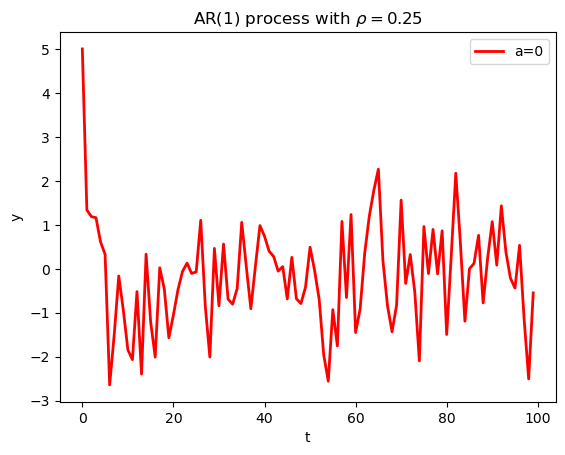

In [78]:
y1 = ar_1_sim(T,rho=0.25)
y2 = ar_1_sim(T,rho=0.25,a=2)

mean_y1 = np.mean(y1)
mean_y2 = np.mean(y2)

print('mean of Ar(1) y1:', mean_y1)
print('mean of Ar(1) y1:', mean_y2)

fig, ax = plt.subplots()
ax.plot(range(0,T), y1, linewidth=2.0, color='r',label='a=0')
# ax.plot(range(0,T), y2, linewidth=2.0, color='b', label='a=2')
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_title(r'AR(1) process with $\rho=0.25$')
ax.legend()
plt.show()

##### Non-stationary process, rho>=1

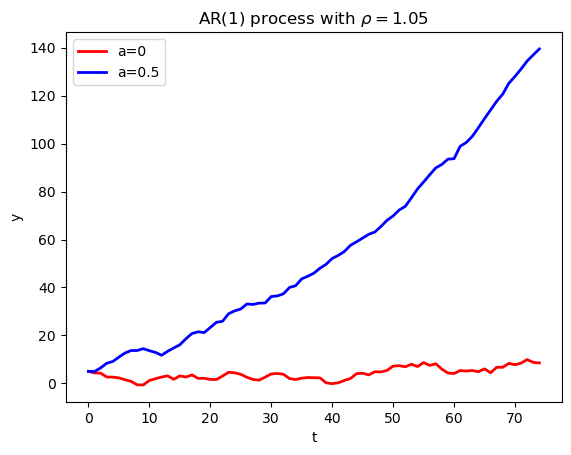

In [80]:
T=75
y3 = ar_1_sim(T,rho=1.02, a=0)
y4 = ar_1_sim(T,rho=1.02, a=0.5)


fig, ax = plt.subplots()
ax.plot(range(0,T), y3, linewidth=2.0, color='r',label='a=0')
ax.plot(range(0,T), y4, linewidth=2.0, color='b',label='a=0.5')
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_title(r'AR(1) process with $\rho=1.05$')
ax.legend()
plt.show()



#### Markov Chains

##### Our income transition probabilities matrix

In [170]:
P1 = [[0.8, 0.15, 0.05],
     [0.25, 0.5, 0.25],
     [0.05, 0.35, 0.6]]

##### Our employment/unemployment transition probabilities

In [172]:
P2 = [[0.5, 0.5],
     [0.7, 0.3]]

First we need to install the quantecon package and then import it as qe

To install it: https://anaconda.org/conda-forge/quantecon

You can also install it from github

##### Now let's create a Markov process based on stochastic matrix P1

In [227]:
# Markov process for income transitions
mc = qe.MarkovChain(P1, state_values=('poor', 'middle','rich')) #object tyoe: Markov Chain
X = mc.simulate(ts_length=10000, init='middle')
# X = mc.simulate(ts_length=10000)

array(['middle', 'rich', 'poor', ..., 'middle', 'middle', 'poor'],
      shape=(10000,), dtype='<U6')

In [233]:
## Average proportion of individuals in each state in the long run
print('Poor:', np.mean(X[-1000:] == 'poor') )
print('Middle:', np.mean(X[-1000:] == 'middle') )
print('Rich:', np.mean(X[-1000:] == 'rich') )

Poor: 0.463
Middle: 0.283
Rich: 0.254


##### In stationarity (that is in the "very" long run)

In [235]:
psi_star = mc.stationary_distributions

print('In this case the Markov matrix has a unique stationary distribution psi* equal to', psi_star)
print('-------------------------------------------------')
print('In the long term in this economy the proportion of people in each class is:')
print('Poor:', round(psi_star[0,0],2) )
print('Middle:', round(psi_star[0,1],2) )
print('Rich:', round(psi_star[0,2],2) )

In this case the Markov matrix has a unique stationary distribution psi* equal to [[0.44554455 0.30693069 0.24752475]]
-------------------------------------------------
In the long term in this economy the proportion of people in each class is:
Poor: 0.45
Middle: 0.31
Rich: 0.25


Note that by increasing N on the simulation by get closer to the stationary distribution

#### 1. Discretizing AR(1) process into a Markov Chain

In [202]:
# 1. Let's have the 2 AR(1) we saw in this class:
y1 = ar_1_sim(10000,rho=0.25, a=0)
y2 = ar_1_sim(10000,rho=0.25,a=2)
mean_y1 = np.mean(y1)
mean_y2 = np.mean(y2)
print('mean of Ar(1) y1:', mean_y1) # approx mu* = a/(1-rho) = 0
print('mean of Ar(1) y2:', mean_y2)  # approx mu* = a/(1-rho) = 2/(1-0.25) =2.66


mean of Ar(1) y1: -0.0065236420560398556
mean of Ar(1) y2: 2.6605592938971108


#### 2. Let's discretize the AR(1)s in two markov processes with 5 possible states

In [97]:
# from quantecon.markov.approximation import rouwenhorst   #both methods work for me
from quantecon import rouwenhorst  # not necessary since I already imported quantecon as qe.

##### AR(1)

In [258]:
#rouwenhorst(n, rho, sigma, mu=0.0)
mc_ar1 = rouwenhorst(5,0.25,1, mu=0)
P1 = mc_ar1.P
psi1_star = mc_ar1.stationary_distributions
y1_values = mc_ar1.state_values

In [264]:
psi1_star

array([[0.0625, 0.25  , 0.375 , 0.25  , 0.0625]])

##### The expected value (mu*) of y1 is:

In [101]:
mean_mc_y1 =  psi1_star@y1_values   # note that matrix product is equivalent to sum(p_i*y_i)
print('mean of Ar(1) y1:', mean_y1)
print('mean MC approx of AR(1) y1:', mean_mc_y1)

mean of Ar(1) y1: -0.02591432215241978
mean MC approx of AR(1) y1: [0.]


In [102]:
mc_ar2 = rouwenhorst(5,0.25,1, mu=2)
P2 = mc_ar2.P
psi2_star = mc_ar2.stationary_distributions
y2_values = mc_ar2.state_values

##### The expected value (mu*) of y2 is:

In [104]:
mean_mc_y2 =  psi2_star@y2_values
print('mean of Ar(1) y2:', mean_y2)
print('mean MC approx of AR(1) y1:', mean_mc_y2)


mean of Ar(1) y2: 2.671214658108544
mean MC approx of AR(1) y1: [2.66666667]


---

## Before the lab

- **Try it:** in the AR(1) simulator, set `rho=1.05` and watch what non-stationarity does to the path. Then set the Markov chain's transition matrix rows to be identical — what happens to the stationary distribution?
- Work through [PS3](../psets/PS3_ECNM10115.pdf) with your group.
- Extra reading: [Quadrature Methods](../files/Quadrature_Methods.pdf).

*Next week: Numerical Methods I — root-finding and optimisation.*